# CalmFruits — неделя 3: эксперименты и выбор конфигурации

Эта тетрадь воспроизводит baseline и сравнивает три изолированных улучшения на зафиксированном validation golden-set. Официальная test-разметка здесь не читается.

In [1]:
from __future__ import annotations

import importlib.metadata
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from joblib import load
from scipy import sparse
from sentence_transformers import SentenceTransformer

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists(): ROOT = ROOT.parent
assert (ROOT / 'src' / 'calmfruits').exists()
sys.path.insert(0, str(ROOT / 'src'))

from calmfruits.catalog import clean_query
from calmfruits.data import load_local_env, read_parquet_from_s3
from calmfruits.eda import join_text_fields
from calmfruits.evaluation import K_VALUES, RELEVANCE_THRESHOLD, evaluate_search, summarize_metrics
from calmfruits.experiments import (HybridSearch, ProjectedSemanticSearch, apply_projection, build_hard_triplets, train_shared_projection)
from calmfruits.provenance import dataframe_fingerprint, file_fingerprint, write_manifest
from calmfruits.search import LexicalSearch, SemanticSearch, SEMANTIC_BATCH_SIZE, SEMANTIC_MODEL, SEMANTIC_REVISION
from calmfruits.tracking import EXPERIMENT_NAME, configure_mlflow, experiment_id, log_evaluation_run

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
CATALOG_DIR = ROOT / 'artifacts' / 'catalog'
INDEX_DIR = ROOT / 'artifacts' / 'indexes'
EVALUATION_DIR = ROOT / 'artifacts' / 'evaluation'
EXPERIMENT_DIR = ROOT / 'artifacts' / 'experiments'
REPORT_DIR = ROOT / 'reports'
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
assert load_local_env(ROOT / '.env')
environment = pd.DataFrame({'value': {'python': sys.version.split()[0], 'pandas': importlib.metadata.version('pandas'), 'torch': importlib.metadata.version('torch'), 'mlflow': importlib.metadata.version('mlflow'), 'seed': SEED, 'device': 'CPU', 'K': K_VALUES, 'relevance_threshold': RELEVANCE_THRESHOLD, 'semantic_model': SEMANTIC_MODEL, 'semantic_revision': SEMANTIC_REVISION}})
display(environment)


,value
python,3.12.6
pandas,2.2.3
torch,2.12.0
mlflow,3.10.0
seed,42
device,CPU
K,"(1, 3, 5, 10)"
relevance_threshold,2
semantic_model,sentence-transformers/paraphrase-multilingual-...
semantic_revision,e8f8c211226b894fcb81acc59f3b34ba3efd5f42


## 1. Зафиксированные данные, каталог и MLflow

Загружаем только сохранённые артефакты второй недели и исходный train для development. Проверяем fingerprints до экспериментов.

In [2]:
catalog = pd.read_parquet(CATALOG_DIR / 'evaluation_catalog.parquet')
queries_train = read_parquet_from_s3('queries_synthetic_train.parquet')
query_split = pd.read_csv(EVALUATION_DIR / 'query_split.csv')
golden = pd.read_parquet(EVALUATION_DIR / 'golden_validation.parquet')
manifest = json.loads((INDEX_DIR / 'index_manifest.json').read_text())
assert catalog.imt_id.astype(int).tolist() == manifest['catalog']['imt_id_order']
assert set(golden.query_id) == set(query_split.loc[query_split['split'].eq('validation'), 'query_id'])
assert set(query_split.loc[query_split['split'].eq('development'), 'normalized_query_text']).isdisjoint(set(query_split.loc[query_split['split'].eq('validation'), 'normalized_query_text']))
assert golden.equals(queries_train.loc[queries_train.query_id.isin(golden.query_id)].sort_values(['query_id', 'item_id']).reset_index(drop=True))
development = queries_train.loc[queries_train.query_id.isin(query_split.loc[query_split['split'].eq('development'), 'query_id'])].copy()
fingerprints = {'catalog': dataframe_fingerprint(catalog, ['imt_id', 'product_text']), 'split': dataframe_fingerprint(query_split, ['query_id', 'normalized_query_text', 'split']), 'golden': dataframe_fingerprint(golden, ['query_id', 'item_id', 'relevance']), 'baseline_manifest': file_fingerprint(INDEX_DIR / 'index_manifest.json')}
write_manifest(EXPERIMENT_DIR / 'protocol_manifest.json', {'seed': SEED, 'K': K_VALUES, 'relevance_threshold': RELEVANCE_THRESHOLD, 'catalog_size': len(catalog), 'fingerprints': fingerprints})
client = configure_mlflow(); mlflow_experiment_id = experiment_id(client)
display(pd.DataFrame({'value': {**fingerprints, 'catalog_size': len(catalog), 'development_queries': development.query_id.nunique(), 'validation_queries': golden.query_id.nunique(), 'mlflow_experiment_id': mlflow_experiment_id}}))


,value
catalog,1d23d0cdb2856a538de5fa8e2590887b5eff3d890ae934...
split,51874816b5b4da2c10b4c718bf7299548d792c7b98aebc...
golden,9a36bd9a8e3418bd1222c11f88857bfe6677dfc0864ba9...
baseline_manifest,39515dd885e2c296fea59d300a79bd5e929507cf2cb051...
catalog_size,3280
development_queries,560
validation_queries,140
mlflow_experiment_id,1


**Вывод по `fingerprints` и assertions.** Зафиксирован каталог из 3 280 карточек, split 560/140 и golden-set 140 validation-запросов; хеши каталога, split, golden-set и baseline-манифеста сохранены в `protocol_manifest.json`. MLflow experiment создан и доступен как experiment id 1.

## 2. Повторный baseline на golden-set

Перед экспериментами воспроизводим TF-IDF и исходный MiniLM на тех же 140 validation-запросах.

In [3]:
lexical = LexicalSearch(catalog, load(INDEX_DIR / 'tfidf_vectorizer.joblib'), sparse.load_npz(INDEX_DIR / 'tfidf_matrix.npz'))
base_model = SentenceTransformer(SEMANTIC_MODEL, revision=SEMANTIC_REVISION, device='cpu')
semantic = SemanticSearch(catalog, base_model, np.load(INDEX_DIR / 'semantic_embeddings.npy'))
baseline_rows = []
baseline_artifacts = []
for method, search in [('lexical', lexical.search_lexical), ('semantic_full_text', semantic.search_semantic)]:
    per_query, top10 = evaluate_search(search, golden, catalog.imt_id, method)
    summary = summarize_metrics(per_query)
    path = EXPERIMENT_DIR / method; path.mkdir(parents=True, exist_ok=True)
    per_query.to_csv(path / 'per_query_metrics.csv', index=False); top10.to_parquet(path / 'top10.parquet', index=False); summary.to_csv(path / 'summary.csv', index=False)
    baseline_rows.append(summary)
    baseline_artifacts.append((method, summary, path, per_query, top10))
baseline_summary = pd.concat(baseline_rows, ignore_index=True)
display(baseline_summary)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,method,mrr,precision_at_1,recall_at_1,hit_rate_at_1,ndcg_at_1,precision_at_3,recall_at_3,hit_rate_at_3,ndcg_at_3,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10
0,lexical,0.376057,0.250000,0.137608,0.250000,0.267347,0.202381,0.286913,0.442857,0.367170,0.167143,0.377675,0.514286,0.407521,0.124286,0.529084,0.628571,0.436972
1,semantic_full_text,0.243173,0.164286,0.068364,0.164286,0.165306,0.133333,0.156768,0.257143,0.208258,0.121429,0.235020,0.335714,0.238042,0.087857,0.309599,0.414286,0.246223


**Вывод по `baseline_summary`.** Воспроизведённые validation-метрики совпали с результатами второй недели: TF-IDF имеет NDCG@10 0,437 и MRR 0,376, полный MiniLM — 0,246 и 0,243. Эти результаты являются общей точкой отсчёта экспериментов.

## 3. Эксперимент 1 — короткий товарный текст

Гипотеза: `imt_name . subj_name` уменьшит усечение входов и повысит семантическое ранжирование относительно полного MiniLM без изменения модели или протокола.

In [4]:
short_catalog = catalog.copy(); short_catalog['product_text'] = join_text_fields(short_catalog, ['imt_name', 'subj_name'])
short_semantic = SemanticSearch.fit(short_catalog, batch_size=SEMANTIC_BATCH_SIZE)
short_dir = EXPERIMENT_DIR / 'semantic_short_text'; short_semantic.save(short_dir)
short_per_query, short_top10 = evaluate_search(short_semantic.search_semantic, golden, catalog.imt_id, 'semantic_short_text')
short_summary = summarize_metrics(short_per_query)
short_per_query.to_csv(short_dir / 'per_query_metrics.csv', index=False); short_top10.to_parquet(short_dir / 'top10.parquet', index=False); short_summary.to_csv(short_dir / 'summary.csv', index=False)
short_truncation = short_semantic.truncation_statistics(short_catalog.product_text.tolist())
display(short_truncation)
display(short_summary)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,texts,max_seq_length,median_tokens,p95_tokens,max_tokens,truncated_share
0,3280,128,12.0,27.0,46,0.0


,method,mrr,precision_at_1,recall_at_1,hit_rate_at_1,ndcg_at_1,precision_at_3,recall_at_3,hit_rate_at_3,ndcg_at_3,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10
0,semantic_short_text,0.182499,0.1,0.057223,0.1,0.09898,0.090476,0.131725,0.2,0.135441,0.074286,0.181997,0.257143,0.15286,0.062143,0.275948,0.357143,0.177939


**Вывод по `short_truncation` и `short_summary`.** Короткий текст устранил усечение входов, но снизил NDCG@10 MiniLM с 0,246 до 0,178. Гипотеза о пользе простого удаления описаний отклоняется: значимая информация из описаний перевесила эффект усечения.

## 4. Эксперимент 2 — RRF-гибрид

Гипотеза: fusion сохранит точные совпадения TF-IDF и добавит случаи, где исходный MiniLM был сильнее. Вес выбирается на development; validation используется только один раз для выбранного веса.

In [5]:
alphas = (0.1, 0.25, 0.5, 0.75, 0.9)
hybrid_dev_rows = []
for alpha in alphas:
    hybrid = HybridSearch(lexical, semantic, alpha=alpha)
    dev_metrics, _ = evaluate_search(hybrid.search_hybrid, development, catalog.imt_id, f'hybrid_alpha_{alpha}')
    summary = summarize_metrics(dev_metrics).assign(alpha=alpha)
    hybrid_dev_rows.append(summary)
hybrid_dev_summary = pd.concat(hybrid_dev_rows, ignore_index=True).sort_values(['ndcg_at_10', 'mrr', 'alpha'], ascending=[False, False, True]).reset_index(drop=True)
selected_alpha = float(hybrid_dev_summary.iloc[0].alpha)
hybrid = HybridSearch(lexical, semantic, alpha=selected_alpha)
hybrid_per_query, hybrid_top10 = evaluate_search(hybrid.search_hybrid, golden, catalog.imt_id, 'hybrid_rrf')
hybrid_summary = summarize_metrics(hybrid_per_query)
hybrid_dir = EXPERIMENT_DIR / 'hybrid_rrf'; hybrid_dir.mkdir(parents=True, exist_ok=True)
hybrid_dev_summary.to_csv(hybrid_dir / 'development_alpha_search.csv', index=False); hybrid_per_query.to_csv(hybrid_dir / 'per_query_metrics.csv', index=False); hybrid_top10.to_parquet(hybrid_dir / 'top10.parquet', index=False); hybrid_summary.to_csv(hybrid_dir / 'summary.csv', index=False)
display(hybrid_dev_summary)
display(hybrid_summary.assign(selected_alpha=selected_alpha))


,method,mrr,precision_at_1,recall_at_1,hit_rate_at_1,ndcg_at_1,precision_at_3,recall_at_3,hit_rate_at_3,ndcg_at_3,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,alpha
0,hybrid_alpha_0.25,0.426848,0.285714,0.122163,0.285714,0.241837,0.238095,0.292680,0.492857,0.351312,0.205357,0.399976,0.583929,0.392265,0.159643,0.616704,0.741071,0.438541,0.25
1,hybrid_alpha_0.1,0.408190,0.271429,0.121106,0.271429,0.245918,0.231548,0.285091,0.471429,0.358865,0.197500,0.395072,0.569643,0.404838,0.148214,0.573037,0.694643,0.436944,0.10
2,hybrid_alpha_0.5,0.402034,0.260714,0.110079,0.260714,0.226531,0.227976,0.261970,0.453571,0.319226,0.194643,0.364877,0.560714,0.351098,0.150536,0.543846,0.700000,0.381937,0.50
3,hybrid_alpha_0.75,0.361007,0.251786,0.106319,0.251786,0.214031,0.205952,0.228332,0.408929,0.283267,0.178571,0.308431,0.489286,0.308095,0.126964,0.420147,0.569643,0.317676,0.75
4,hybrid_alpha_0.9,0.335015,0.246429,0.106327,0.246429,0.199490,0.186310,0.202348,0.376786,0.255160,0.155000,0.261979,0.433929,0.268841,0.113571,0.366080,0.510714,0.280414,0.90


,method,mrr,precision_at_1,recall_at_1,hit_rate_at_1,ndcg_at_1,precision_at_3,recall_at_3,hit_rate_at_3,ndcg_at_3,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,selected_alpha
0,hybrid_rrf,0.378211,0.25,0.117369,0.25,0.243878,0.216667,0.301436,0.435714,0.348829,0.181429,0.394997,0.528571,0.394752,0.132143,0.531861,0.628571,0.424481,0.25


**Вывод по `hybrid_dev_summary` и `hybrid_summary`.** На development лучшим оказался alpha=0,25. На единственной validation-оценке RRF повысил MRR до 0,378 и Precision@5 до 0,181, но NDCG@10 снизился до 0,424 относительно TF-IDF. Гипотеза о выигрыше гибрида по основной метрике отклоняется.

## 5. Эксперимент 3 — общая обучаемая проекция

Гипотеза: единая линейная проекция замороженных MiniLM-векторов, обученная только на development-триплетах, приблизит запросы к релевантным товарам без изменения энкодера.

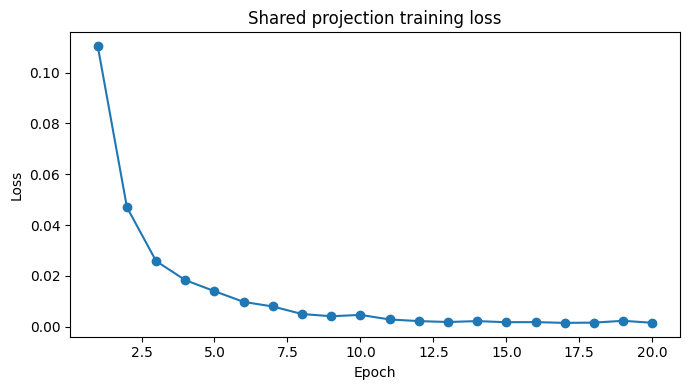

,value
positive_ids,1468
negative_ids,2655
triplets,4422


,method,mrr,precision_at_1,recall_at_1,hit_rate_at_1,ndcg_at_1,precision_at_3,recall_at_3,hit_rate_at_3,ndcg_at_3,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10
0,semantic_projected,0.119895,0.05,0.030238,0.05,0.052041,0.059524,0.099121,0.142857,0.091429,0.047143,0.129436,0.192857,0.096707,0.034286,0.164478,0.242857,0.09613


,weight_l2_distance_from_identity
0,12.923008


In [6]:
anchors, positives, negatives, triplet_diagnostics = build_hard_triplets(development, catalog.imt_id, base_model, semantic.embeddings, seed=SEED)
assert set(triplet_diagnostics.query_id).issubset(set(development.query_id))
weights, loss_history = train_shared_projection(anchors, positives, negatives, seed=SEED)
projected_embeddings = apply_projection(semantic.embeddings, weights)
projected = ProjectedSemanticSearch(catalog, base_model, projected_embeddings, weights)
projection_dir = EXPERIMENT_DIR / 'semantic_projected'; projected.save(projection_dir)
projection_per_query, projection_top10 = evaluate_search(projected.search_projected, golden, catalog.imt_id, 'semantic_projected')
projection_summary = summarize_metrics(projection_per_query)
triplet_diagnostics.to_csv(projection_dir / 'triplet_diagnostics.csv', index=False); loss_history.to_csv(projection_dir / 'loss_history.csv', index=False); projection_per_query.to_csv(projection_dir / 'per_query_metrics.csv', index=False); projection_top10.to_parquet(projection_dir / 'top10.parquet', index=False); projection_summary.to_csv(projection_dir / 'summary.csv', index=False)
fig, ax = plt.subplots(figsize=(7, 4)); ax.plot(loss_history.epoch, loss_history.loss, marker='o'); ax.set(xlabel='Epoch', ylabel='Loss', title='Shared projection training loss'); fig.tight_layout(); fig.savefig(projection_dir / 'loss_by_epoch.png', dpi=150); plt.show()
display(triplet_diagnostics.agg({'positive_ids':'sum', 'negative_ids':'sum', 'triplets':'sum'}).to_frame('value'))
display(projection_summary)
display(pd.DataFrame({'weight_l2_distance_from_identity':[float(np.linalg.norm(weights - np.eye(384)))]}))


**Вывод по `triplet_diagnostics`, `loss_history` и `projection_summary`.** Проекция обучена на development-триплетах, а loss по эпохам сохранён в `loss_by_epoch.png`. На validation NDCG@10 составил 0,096, что существенно ниже исходного MiniLM 0,246; гипотеза об улучшении общей линейной проекцией отклоняется.

## 6. MLflow, выбор решения и качественный разбор

Логируем два baseline и три validation-эксперимента. Победитель выбирается по NDCG@10, затем MRR и заданному порядку предпочтений.

In [7]:
all_summaries = pd.concat([baseline_summary, short_summary, hybrid_summary, projection_summary], ignore_index=True)
method_order = {'lexical':0, 'semantic_full_text':1, 'semantic_short_text':2, 'semantic_projected':3, 'hybrid_rrf':4}
all_summaries['preference'] = all_summaries.method.map(method_order)
validation_comparison = all_summaries.sort_values(['ndcg_at_10', 'mrr', 'preference'], ascending=[False, False, True]).reset_index(drop=True)
winner = validation_comparison.iloc[0].to_dict()
run_ids = {}
run_payloads = baseline_artifacts + [('semantic_short_text', short_summary, short_dir, short_per_query, short_top10), ('hybrid_rrf', hybrid_summary, hybrid_dir, hybrid_per_query, hybrid_top10), ('semantic_projected', projection_summary, projection_dir, projection_per_query, projection_top10)]
for method, summary, path, _, _ in run_payloads:
    params = {'method': method, 'eval_split':'validation', 'catalog_size':len(catalog), 'relevance_threshold':RELEVANCE_THRESHOLD, 'seed':SEED, 'K':K_VALUES, 'model':SEMANTIC_MODEL if method != 'lexical' else 'tfidf', 'model_revision':SEMANTIC_REVISION if method != 'lexical' else 'n/a', 'protocol_fingerprint':fingerprints['golden'], 'git_commit':__import__('subprocess').check_output(['git','rev-parse','HEAD'], text=True).strip()}
    if method == 'hybrid_rrf': params.update({'rrf_k':60, 'alpha':selected_alpha})
    if method == 'semantic_projected': params.update({'epochs':20, 'learning_rate':0.001, 'margin':0.2, 'regularization':0.001, 'projection_dimension':384})
    run_ids[method] = log_evaluation_run(f'{method}_validation', params, summary, [path / 'per_query_metrics.csv', path / 'summary.csv', EVALUATION_DIR / 'golden_validation.parquet'])
validation_comparison.to_csv(REPORT_DIR / 'validation_experiment_comparison.csv', index=False)
write_manifest(REPORT_DIR / 'selected_configuration.json', {'winner': winner, 'run_ids':run_ids, 'selected_alpha':selected_alpha, 'fingerprints':fingerprints, 'selection_rule':'max ndcg_at_10, then mrr, then preference'})
display(validation_comparison)
display(pd.DataFrame({'method':list(run_ids), 'mlflow_run_id':list(run_ids.values())}))


🏃 View run lexical_validation at: https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru/#/experiments/1/runs/12fc2b3407e9429fb95babd7b7ebde01
🧪 View experiment at: https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru/#/experiments/1


🏃 View run semantic_full_text_validation at: https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru/#/experiments/1/runs/1daf6f71e68a41fa85d54d4344537e30
🧪 View experiment at: https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru/#/experiments/1


🏃 View run semantic_short_text_validation at: https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru/#/experiments/1/runs/250246c7205f44999e6be9bb61992a80
🧪 View experiment at: https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru/#/experiments/1


🏃 View run hybrid_rrf_validation at: https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru/#/experiments/1/runs/8e2fe62fbd614af191c66a387e439eeb
🧪 View experiment at: https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru/#/experiments/1


🏃 View run semantic_projected_validation at: https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru/#/experiments/1/runs/5b7f5f2d09874c73a2b536b3cdf92324
🧪 View experiment at: https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru/#/experiments/1


,method,mrr,precision_at_1,recall_at_1,hit_rate_at_1,ndcg_at_1,precision_at_3,recall_at_3,hit_rate_at_3,ndcg_at_3,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,preference
0,lexical,0.376057,0.250000,0.137608,0.250000,0.267347,0.202381,0.286913,0.442857,0.367170,0.167143,0.377675,0.514286,0.407521,0.124286,0.529084,0.628571,0.436972,0
1,hybrid_rrf,0.378211,0.250000,0.117369,0.250000,0.243878,0.216667,0.301436,0.435714,0.348829,0.181429,0.394997,0.528571,0.394752,0.132143,0.531861,0.628571,0.424481,4
2,semantic_full_text,0.243173,0.164286,0.068364,0.164286,0.165306,0.133333,0.156768,0.257143,0.208258,0.121429,0.235020,0.335714,0.238042,0.087857,0.309599,0.414286,0.246223,1
3,semantic_short_text,0.182499,0.100000,0.057223,0.100000,0.098980,0.090476,0.131725,0.200000,0.135441,0.074286,0.181997,0.257143,0.152860,0.062143,0.275948,0.357143,0.177939,2
4,semantic_projected,0.119895,0.050000,0.030238,0.050000,0.052041,0.059524,0.099121,0.142857,0.091429,0.047143,0.129436,0.192857,0.096707,0.034286,0.164478,0.242857,0.096130,3


,method,mlflow_run_id
0,lexical,12fc2b3407e9429fb95babd7b7ebde01
1,semantic_full_text,1daf6f71e68a41fa85d54d4344537e30
2,semantic_short_text,250246c7205f44999e6be9bb61992a80
3,hybrid_rrf,8e2fe62fbd614af191c66a387e439eeb
4,semantic_projected,5b7f5f2d09874c73a2b536b3cdf92324


**Вывод по `validation_comparison` и `run_ids`.** Все пять validation-конфигураций завершены и залогированы в MLflow. По NDCG@10 выбран TF-IDF (0,437); гибрид RRF второй (0,424). `selected_configuration.json` фиксирует победителя, fingerprints и run IDs до открытия test.

## 7. Ошибки выбранной конфигурации

Показываем три validation-запроса с наименьшим NDCG@10 у победителя и их top-10, чтобы ограничения опирались на фактическую выдачу.

In [8]:
metrics_by_method = {method: per_query for method, _, _, per_query, _ in run_payloads}
top_by_method = {method: top10 for method, _, _, _, top10 in run_payloads}
winner_method = winner['method']
worst_queries = metrics_by_method[winner_method].nsmallest(3, 'ndcg_at_10')[['query_id','query_text','ndcg_at_10','mrr']]
winner_errors = top_by_method[winner_method].merge(worst_queries[['query_id']], on='query_id', how='inner')
winner_labels = golden.merge(worst_queries[['query_id']], on='query_id', how='inner').sort_values(['query_id','relevance'], ascending=[True,False])
display(worst_queries)
display(winner_errors[['query_id','rank','imt_id','relevance','imt_name','subj_name','score']])
display(winner_labels[['query_id','query_text','item_id','relevance']])


,query_id,query_text,ndcg_at_10,mrr
36,SYN_000250,классические костюмы,0.0,0.010417
39,SYN_000267,топы lollytic,0.0,0.027778
50,SYN_000347,дышащий топы,0.0,0.013333


,query_id,rank,imt_id,relevance,imt_name,subj_name,score
0,SYN_000250,1,10013487,0,Брюки мужские классические,Брюки,0.188854
1,SYN_000250,2,10056537,0,Костюмы,Костюмы,0.177196
2,SYN_000250,3,10030679,0,Спортивный костюм женский,Костюмы,0.168297
3,SYN_000250,4,10114653,0,Брюки женские/Укороченные классические,Брюки,0.161295
4,SYN_000250,5,10110243,0,Брюки мужские классические,Брюки,0.161191
5,SYN_000250,6,10069135,0,Костюмы,Костюмы,0.155955
6,SYN_000250,7,10042991,0,Туфли кожаные классические,Туфли,0.153175
7,SYN_000250,8,10017128,0,Классические брюки,Брюки,0.150513
8,SYN_000250,9,10030082,0,Брюки женские летние классические зауженные ук...,Брюки,0.146914
9,SYN_000250,10,10006191,0,Костюм,Костюмы,0.137063


,query_id,query_text,item_id,relevance
9,SYN_000250,классические костюмы,10029220,3
10,SYN_000250,классические костюмы,10045198,2
13,SYN_000250,классические костюмы,10068018,2
0,SYN_000250,классические костюмы,101726,1
1,SYN_000250,классические костюмы,101823,1
2,SYN_000250,классические костюмы,1001743,1
3,SYN_000250,классические костюмы,10012939,1
4,SYN_000250,классические костюмы,10018873,1
5,SYN_000250,классические костюмы,10019494,1
6,SYN_000250,классические костюмы,10020136,1


**Вывод по `worst_queries`, `winner_errors` и `winner_labels`.** Даже выбранный TF-IDF ошибается на запросах без достаточного буквального совпадения или при неполной разметке. Для дальнейшего развития полезны реальные логи запросов и кликов, а также более обоснованный гибрид или дообучение с отдельной validation-проверкой.